# 05 Modelo Segmentación Clientes

Este notebook transforma la base `EDA` a nivel cliente, entrena `K-Means` y exporta el `Parquet` final de segmentación.


## 1. Librerías


In [1]:
# Manejo de rutas internas del proyecto.
from pathlib import Path
# Guardado de listas de variables en formato JSON.
import json

# Persistencia del modelo entrenado.
import joblib
# Manejo tabular de la base EDA y de la base agregada por cliente.
import pandas as pd
# Gráficas generales del modelo.
import matplotlib.pyplot as plt
# Visualizaciones estadísticas para clusters y comportamiento de gasto.
import seaborn as sns
# Algoritmo de segmentación no supervisada.
from sklearn.cluster import KMeans
# Preparación de columnas numéricas antes de agrupar clientes.
from sklearn.compose import ColumnTransformer
# Métrica para evaluar la separación entre clusters.
from sklearn.metrics import silhouette_score
# Construcción del flujo completo de transformación y clustering.
from sklearn.pipeline import Pipeline
# Escalamiento numerico para evitar que una variable domine a las demas.
from sklearn.preprocessing import StandardScaler


### Para qué se usan estas librerías

- `Path`: localizar la raíz del proyecto y construir rutas de entrada, salida y guardado del modelo.
- `json`: guardar la lista final de variables utilizadas por el modelo.
- `joblib`: exportar el modelo ya entrenado para retilizarlo.
- `pandas`: leer la base `EDA`, construir la agregación por cliente y preparar la salida final.
- `matplotlib` y `seaborn`: generar visualizaciones de apoyo para revisar los clusters.
- `ColumnTransformer`, `Pipeline` y `StandardScaler`: preparar las variables numéricas antes del clustering.
- `KMeans`: entrenar el modelo de segmentación de clientes.
- `silhouette_score`: medir que tan bien separados quedan los grupos encontrados.


## 2. Definír rutas


### Nota sobre nombres técnicos

En el código y en las columnas técnicas se usa `anio` en lugar de `año`. La letra `ñ` se deja solo en el texto explicativo, pero no en nombres de variables, columnas o archivos para evitar caracteres especiales y mantener compatibilidad.


In [2]:
from pathlib import Path

def resolve_project_root() -> Path:
    # Buscar la raíz del proyecto a partir del directorio actual.
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() and (candidate / "parquets").exists():
            return candidate
    raise FileNotFoundError("No se pudo localizar la raiz del proyecto")

PROJECT_ROOT = resolve_project_root()

# Definír las rutas de entrada y salida de la etapa 05.
INPUT_PATH = PROJECT_ROOT / "parquets" / "02_EDA_Base_Tickets" / "02_base_eda_tickets.parquet"
OUTPUT_DIR = PROJECT_ROOT / "parquets" / "05_Modelo_Segmentacion_Clientes"
OUTPUT_PATH = OUTPUT_DIR / "05_clientes_segmentados.parquet"
MODEL_DIR = PROJECT_ROOT / "models" / "05_Modelo_Segmentacion_Clientes"
MODEL_PATH = MODEL_DIR / "05_modelo_kmeans.joblib"
FEATURES_PATH = MODEL_DIR / "05_features_kmeans.json"

print(f"Raiz del proyecto: {PROJECT_ROOT}")
print(f"Parquet de entrada: {INPUT_PATH}")
print(f"Parquet de salida: {OUTPUT_PATH}")
print(f"Modelo entrenado: {MODEL_PATH}")


Raiz del proyecto: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning
Parquet de entrada: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\parquets\02_EDA_Base_Tickets\02_base_eda_tickets.parquet
Parquet de salida: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\parquets\05_Modelo_Segmentacion_Clientes\05_clientes_segmentados.parquet
Modelo entrenado: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\models\05_Modelo_Segmentacion_Clientes\05_modelo_kmeans.joblib


## 3. Cargar la base EDA


In [3]:
# Leer la base EDA y preparar la fecha para calculos temporales.
df = pd.read_parquet(INPUT_PATH)
df["fecha"] = pd.to_datetime(df["fecha"])

# Mostrar las primeras filas de la base de entrada.
df.head()


,id_ticket_modelado,fecha,anio_mes,dia,mes,nombre_mes,trimestre,anio,dia_semana,dia_tipo,...,residuo_abs_subtotal_total,residuo_pago_total,ticket_consistente_subtotal,ticket_consistente_pago,incluye_bebida,incluye_postre,incluye_entrada,incluye_platillo_fuerte,ticket_alto,rango_total_pedido
0,1,2024-01-02,2024-01,2,1,Enero,1,2024,Martes,Entre semana,...,695.0,0.0,0,1,0,0,0,1,0,Bajo
1,2,2024-01-03,2024-01,3,1,Enero,1,2024,Miércoles,Entre semana,...,3580.0,0.0,0,1,1,1,1,1,0,Bajo
2,3,2024-01-03,2024-01,3,1,Enero,1,2024,Miércoles,Entre semana,...,4750.0,0.0,0,1,1,1,1,1,0,Medio
3,4,2024-01-03,2024-01,3,1,Enero,1,2024,Miércoles,Entre semana,...,1115.0,-65.0,0,0,1,0,0,1,0,Medio
4,5,2024-01-03,2024-01,3,1,Enero,1,2024,Miércoles,Entre semana,...,125.0,0.0,0,1,0,0,0,1,0,Medio


### Resultado

La base `EDA` se cargo correctamente desde `02_base_eda_tickets.parquet`.

La vista previa muestra `5 filas x 43 columnas`, lo que confirma que la etapa de segmentación parte de la misma base enriquecida usada en los modelos supervisados.

En esta etapa todavía se observa información a nivel ticket, pero ya lista para agregarse por cliente y construir una vista histórica de comportamiento.

En los nombres técnicos se mantiene `anio` sin `ñ` por compatibilidad con columnas, archivos y artefactos del modelo.


## 4. Construir la base por cliente


In [4]:
# Obtener la fecha maxima para calcular recencia.
fecha_max = df["fecha"].max()

# Construir la base agregada a nivel cliente.
# Aquí cada fila deja de representar un ticket y pasa a representar un cliente.
clientes = (
    df.groupby("id_cliente", dropna=False)
    .agg(
        numero_tickets=("id_ticket_modelado", "nunique"),
        gasto_total=("total_pedido", "sum"),
        ticket_promedio=("total_pedido", "mean"),
        ticket_maximo=("total_pedido", "max"),
        cantidad_total_productos=("cantidad_total", "sum"),
        promedio_productos_ticket=("cantidad_total", "mean"),
        platillos_distintos_totales=("platillos_distintos", "sum"),
        categorias_distintas_totales=("categorias_distintas", "sum"),
        ultimo_ticket=("fecha", "max"),
        primer_ticket=("fecha", "min"),
        ciudades_visitadas=("ciudad", "nunique"),
        sucursales_visitadas=("id_sucursal", "nunique"),
        usa_bebida=("incluye_bebida", "max"),
        usa_postre=("incluye_postre", "max"),
        usa_entrada=("incluye_entrada", "max"),
        usa_platillo_fuerte=("incluye_platillo_fuerte", "max"),
        metodo_pago_frecuente=("metodo_pago", lambda s: s.mode().iloc[0] if not s.mode().empty else "Sin dato"),
    )
    .reset_index()
)

# Derivar columnas de permanencia y recencia.
clientes["dias_activos"] = (clientes["ultimo_ticket"] - clientes["primer_ticket"]).dt.days + 1
clientes["dias_desde_ultimo_ticket"] = (fecha_max - clientes["ultimo_ticket"]).dt.days
clientes.head()


,id_cliente,numero_tickets,gasto_total,ticket_promedio,ticket_maximo,cantidad_total_productos,promedio_productos_ticket,platillos_distintos_totales,categorias_distintas_totales,ultimo_ticket,primer_ticket,ciudades_visitadas,sucursales_visitadas,usa_bebida,usa_postre,usa_entrada,usa_platillo_fuerte,metodo_pago_frecuente,dias_activos,dias_desde_ultimo_ticket
0,1,2,565.0,282.5,285.0,44,22.0,21,12,2024-05-01,2024-01-03,1,1,1,1,1,1,Efectivo,120,244
1,2,2,1045.0,522.5,625.0,53,26.5,21,12,2024-05-08,2024-01-03,1,1,1,1,1,1,Tarjeta de crédito,127,237
2,3,2,570.0,285.0,375.0,51,25.5,23,12,2024-05-15,2024-01-04,1,1,1,1,1,1,Efectivo,133,230
3,4,2,815.0,407.5,560.0,65,32.5,29,10,2024-05-22,2024-01-04,1,1,1,1,1,1,Efectivo,140,223
4,5,2,810.0,405.0,500.0,76,38.0,28,11,2024-05-29,2024-01-05,1,1,1,1,1,1,Efectivo,146,216


### Resultado

Después de la agregación, la base pasa de tickets a clientes como unidad de análisis.

La vista previa muestra `5 filas x 19 columnas`, lo que refleja que ya se condensaron variables históricas por cliente, como `numero_tickets`, `gasto_total`, `ticket_promedio`, `dias_activos` y `dias_desde_ultimo_ticket`.

Con está transformación, la etapa `05` deja de estudiar compras individuales y empieza a describir patrones de consumo por cliente.


## 5. Seleccionar variables y entrenar el modelo


In [5]:
# Definír las variables numéricas para segmentación.
# Se usan solo variables cuantitativas porque K-Means trabaja sobre distancias numéricas.
FEATURES = [
    "numero_tickets",
    "gasto_total",
    "ticket_promedio",
    "ticket_maximo",
    "cantidad_total_productos",
    "promedio_productos_ticket",
    "categorias_distintas_totales",
    "dias_activos",
    "dias_desde_ultimo_ticket",
]

# Definír el preprocesador y el modelo K-Means.
# Se escalan las variables para que ningúna domine por tener valores mas grandes.
preprocessor = ColumnTransformer(
    transformers=[("num", Pipeline(steps=[("scaler", StandardScaler())]), FEATURES)],
    remainder="drop",
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clusterer", KMeans(n_clusters=3, random_state=42, n_init=20)),
])

# Entrenar el modelo de segmentación.
pipeline.fit(clientes[FEATURES])
clientes["cluster"] = pipeline.predict(clientes[FEATURES])
clientes.head()


,id_cliente,numero_tickets,gasto_total,ticket_promedio,ticket_maximo,cantidad_total_productos,promedio_productos_ticket,platillos_distintos_totales,categorias_distintas_totales,ultimo_ticket,...,ciudades_visitadas,sucursales_visitadas,usa_bebida,usa_postre,usa_entrada,usa_platillo_fuerte,metodo_pago_frecuente,dias_activos,dias_desde_ultimo_ticket,cluster
0,1,2,565.0,282.5,285.0,44,22.0,21,12,2024-05-01,...,1,1,1,1,1,1,Efectivo,120,244,2
1,2,2,1045.0,522.5,625.0,53,26.5,21,12,2024-05-08,...,1,1,1,1,1,1,Tarjeta de crédito,127,237,2
2,3,2,570.0,285.0,375.0,51,25.5,23,12,2024-05-15,...,1,1,1,1,1,1,Efectivo,133,230,2
3,4,2,815.0,407.5,560.0,65,32.5,29,10,2024-05-22,...,1,1,1,1,1,1,Efectivo,140,223,2
4,5,2,810.0,405.0,500.0,76,38.0,28,11,2024-05-29,...,1,1,1,1,1,1,Efectivo,146,216,2


## 6. Nombrar segmentos y evaluar el clustering


In [6]:
# Ordenar clusters por gasto y número de tickets para asígnar etiquetas.
ranking = (
    clientes.groupby("cluster")
    .agg(gasto_total_promedio=("gasto_total", "mean"), numero_tickets_promedio=("numero_tickets", "mean"))
    .sort_values(["gasto_total_promedio", "numero_tickets_promedio"])
    .reset_index()
)

etiquetas_base = [
    "Clientes de bajo valor",
    "Clientes de valor medio",
    "Clientes de alto valor",
]

# Convertir el número de cluster en una etiqueta de negocio mas interpretable.
mapping = {row["cluster"]: etiquetas_base[idx] for idx, (_, row) in enumerate(ranking.iterrows())}
clientes["segmento_cliente"] = clientes["cluster"].map(mapping)

# Calcular métricas basícas del clustering.
X_transformed = pipeline.named_steps["preprocessor"].transform(clientes[FEATURES])
métricas = pd.DataFrame(
    {
        "metrica": ["n_clientes", "n_clusters", "inercia", "silhouette"],
        "valor": [
            int(len(clientes)),
            3,
            round(float(pipeline.named_steps["clusterer"].inertia_), 4),
            round(float(silhouette_score(X_transformed, clientes["cluster"])), 4),
        ],
    }
)
métricas


,metrica,valor
0,n_clientes,800.0000
1,n_clusters,3.0000
2,inercia,3206.5986
3,silhouette,0.3836


### Resultado

La base de segmentación trabaja con `9 variables numericas` para describir comportamiento de consumo a nivel cliente.

Después del entrenamiento con `K-Means`, las métricas obtenidas fueron:

- `n_clientes = 800`
- `n_clusters = 3`
- `inercia = 3206.5986`
- `silhouette = 0.3836`

Además, los clusters se tradujeron a etiquetas de negocio para interpretar mejor los grupos encontrados: clientes de bajo valor, valor medio y alto valor.


## 7. Visualizaciones del modelo


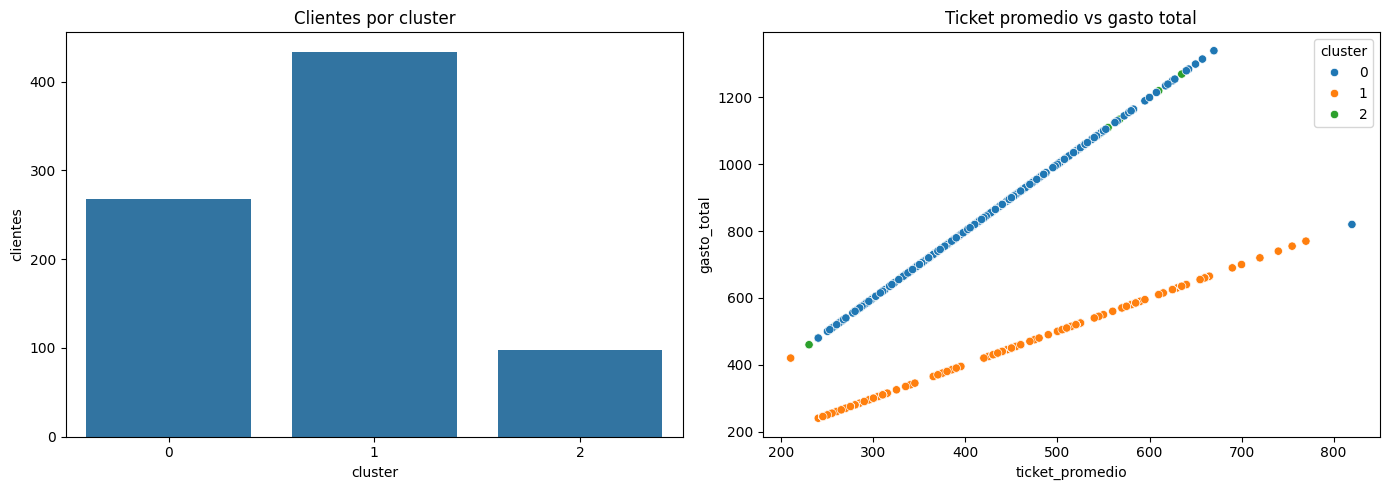

In [7]:
# Graficar la cantidad de clientes por cluster y su comportamiento de gasto.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=clientes, x="cluster", ax=axes[0])
axes[0].set_title("Clientes por cluster")
axes[0].set_xlabel("cluster")
axes[0].set_ylabel("clientes")

# Comparar ticket promedio contra gasto acumulado para observar la separación de grupos.
sns.scatterplot(
    data=clientes,
    x="ticket_promedio",
    y="gasto_total",
    hue="cluster",
    palette="tab10",
    ax=axes[1],
)
axes[1].set_title("Ticket promedio vs gasto total")
axes[1].set_xlabel("ticket_promedio")
axes[1].set_ylabel("gasto_total")
plt.tight_layout()


### Resultado

Las visualizaciones ayudan a revisar el tamaño relativo y el comportamiento económico de cada cluster.

En la **gráfica de conteo por cluster** se observan `3 grupos` con estos tamaños:

- `cluster 0 = 268 clientes`
- `cluster 1 = 434 clientes`
- `cluster 2 = 98 clientes`

Esto indica que el grupo más numeroso es el `cluster 1`, mientras que el `cluster 2` concentra una porción menor de clientes.

En la **dispersión de `ticket_promedio` contra `gasto_total`**, cada punto representa un cliente. El eje horizontal muestra cuánto suele gastar por ticket y el eje vertical cuánto acumula en gasto total. Los colores distinguen los clusters encontrados por `K-Means`. Aquí se aprecia una separación visible entre clientes de menor gasto acumulado y clientes con mayor valor económico, lo cual respalda el uso de segmentos como apoyo para análisis comercial.


## 8. Exportar el parquet final del modelo


In [8]:
# Crear carpetas de salida para la etapa 05.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Exportar la base segmentada y los artefactos técnicos del modelo.
clientes.to_parquet(OUTPUT_PATH, index=False)
joblib.dump(pipeline, MODEL_PATH)
FEATURES_PATH.write_text(json.dumps(FEATURES, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Parquet generado en: {OUTPUT_PATH}")
print(f"Modelo guardado en: {MODEL_PATH}")


Parquet generado en: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\parquets\05_Modelo_Segmentacion_Clientes\05_clientes_segmentados.parquet
Modelo guardado en: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\models\05_Modelo_Segmentacion_Clientes\05_modelo_kmeans.joblib


In [9]:
# Verificar la salida exportada de la etapa 05.
clientes_exportados = pd.read_parquet(OUTPUT_PATH)
clientes_exportados.shape


(800, 22)

### Resultado

El parquet final de segmentación se genero correctamente en la carpeta `parquets/05_Modelo_Segmentacion_Clientes`.

También se guardo el modelo entrenado en la carpeta `models/05_Modelo_Segmentacion_Clientes`.

Después de volver a leer la salida exportada, se confirmó que el archivo final conserva una estructura de:

- `800 filas`
- `22 columnas`

La salida final ya incluye `cluster` y `segmento_cliente` para cada cliente.

Con esto, la etapa `05` queda cerrada con una salida lista para analizar segmentos de clientes en Qlik.


## Conclusión

La etapa `05` transforma la base por ticket en una vista a nivel cliente y permite identificar `3 segmentos` con `800 clientes` en total. El resultado final queda guardado en `05_clientes_segmentados.parquet`, listo para analizar perfiles de clientes y valor de negocio en la visualización.
